# Manual Labeling and Analysis

## 1. Creating Gold Dataset
Creating the Gold Dataset of 1000 rows randomly (with stratification) for the human annotator to label.

In [1]:
import pandas as pd
import os

In [2]:
# Loading my 189k labeled dataset
DATA_DIR = os.path.join("..", "data")
os.makedirs(DATA_DIR, exist_ok=True)

df = pd.read_csv(os.path.join(DATA_DIR, 'comments_llama_labeled.csv'))
df.head()

,comment_id,video_title,video_context,parent_context,text_preprocessed,game_related,target,category,sentiment,confidence,reasoning,api_key_used,tokens_in,tokens_out,parse_ok
0,UgzLPJdZudI_r4we6c94AaABAg,Arc Raiders Reveal Trailer | Game Awards 2021,Check out the world premiere reveal trailer fo...,NaN,Good choice of music,Yes,Game,Game_Related,Pos,0.90,"The comment praises the 'choice of music', whi...",…coJzZw,698,95,True
1,UgyAUoHvzWPWW5jVv994AaABAg,Arc Raiders Reveal Trailer | Game Awards 2021,Check out the world premiere reveal trailer fo...,NaN,this looks VERY fun,Yes,Game,Game_Related,Pos,0.90,"The comment states 'this looks VERY fun', indi...",…Gf-urA,698,98,True
2,UgzwutSd2BKZ6h-6dRF4AaABAg,Arc Raiders Reveal Trailer | Game Awards 2021,Check out the world premiere reveal trailer fo...,NaN,these graphics are sick!,Yes,Game,Game_Related,Pos,0.95,The comment explicitly praises the graphics of...,…InyxBg,699,83,True
3,UgzlrEdJ-IeAuox6BLJ4AaABAg,Arc Raiders Reveal Trailer | Game Awards 2021,Check out the world premiere reveal trailer fo...,NaN,"Ok, Arc Raiders....I see you",Yes,Game,Game_Related,Neu,0.60,"The comment 'Ok, Arc Raiders....I see you' is ...",…coJzZw,702,119,True
4,UgwcSGsGzi8y4_ynAhh4AaABAg,Arc Raiders Reveal Trailer | Game Awards 2021,Check out the world premiere reveal trailer fo...,NaN,came here to shazam the song. The trailer is p...,No,Other,NaN,NaN,NaN,NaN,…Gf-urA,711,18,True


In [16]:
# Stratification
# We want roughly 250 comments per major aspect to ensure balanced validation
df['category_filled'] = df['category'].fillna('Null')

category_goals = {
    'AI_Voice_Related': 250,
    'Business_Model_Related': 250,
    'Game_Related': 250,
    'Null': 250}

In [17]:
gold_samples = []

for category, count in category_goals.items():
    # Filter for the aspect (using the column name from Llama output)
    subset = df[df['category_filled'] == category]
    
    # If the subset is smaller than the goal, take everything available
    n_to_sample = min(len(subset), count)
    
    # Sample and add to our list
    gold_samples.append(subset.sample(n=n_to_sample, random_state=15))

# Combine and Shuffle
gold_df = pd.concat(gold_samples).sample(frac=1, random_state=15)

In [ ]:
# Excluding Llama labels so we can label objectively
blind_cols = [
    'comment_id', 
    'text_preprocessed', 
    'video_title', 
    'video_context',
    'parent_context']

# Empty columns for me to fill
gold_df_blind = gold_df[blind_cols].copy()
gold_df_blind['gold_category'] = ""
gold_df_blind['gold_sentiment'] = ""

In [ ]:
gold_df_blind.to_csv(os.path.join(DATA_DIR, 'gold_set_manual_labels.csv'), index=False)

print(f"Gold set of {len(gold_df_blind)} rows exported.")
print("Next Step: Open this in Excel and fill in 'gold_category' and 'gold_sentiment'.")

Gold set of 1000 rows exported.
Next Step: Open this in Excel and fill in 'gold_category' and 'gold_sentiment'.


## 2. Agreement & Confusion Matrix

In [22]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score, confusion_matrix, classification_report, accuracy_score
DATA_DIR = os.path.join("..", "data")
os.makedirs(DATA_DIR, exist_ok=True)
FIGURES_DIR = os.path.join("..", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

In [25]:
# Loading the data
llama_df = pd.read_csv(os.path.join(DATA_DIR, 'comments_llama_labeled.csv'))
gold_df = pd.read_csv(os.path.join(DATA_DIR, 'gold_set_manual_labels.csv'))

In [29]:
# Merge on comment_id to align human vs. model predictions
# We only care about the 1000 rows where we have human 'Gold' labels
merged_df = pd.merge(
    gold_df[['comment_id', 'gold_category', 'gold_sentiment']], 
    llama_df[['comment_id', 'category', 'sentiment']], 
    on='comment_id', 
    how='inner')

In [33]:
# Check the number of nulls
print("Null values in merged dataset:")
print(merged_df.isnull().sum())

Null values in merged dataset:
comment_id          0
gold_category       0
gold_sentiment    266
category          250
sentiment         250
dtype: int64


In [34]:
# Filling these so that they don't cause issues in metrics calculation. We will treat nulls as a separate category
merged_df['gold_sentiment'] = merged_df['gold_sentiment'].fillna('Null')
merged_df['category'] = merged_df['category'].fillna('Null')
merged_df['sentiment'] = merged_df['sentiment'].fillna('Null')

In [35]:
merged_df.head(20)

,comment_id,gold_category,gold_sentiment,category,sentiment
0,UgwsdyOYEqw1fe8tVa14AaABAg,Null,Null,Null,Null
1,UgyRoNyLQaPJlPd7mlp4AaABAg,Business_Model_Related,Neg,Business_Model_Related,Neg
2,UgzbfDydSmFpNvhmtxh4AaABAg,Business_Model_Related,Neg,Business_Model_Related,Neg
3,UgyYiRjjV9kusqLIUzJ4AaABAg,Game_Related,Neg,Game_Related,Neg
4,Ugw6JeK-GxWedeQoZEx4AaABAg,AI_Voice_Related,Neg,AI_Voice_Related,Neg
5,Ugw2ahBSJfYRl-MUtux4AaABAg,Null,Null,Null,Null
6,UgxOI6vrsqgH3URVbjZ4AaABAg,Game_Related,Neg,AI_Voice_Related,Neg
7,UgxBgWcKBSd0vc4nuHl4AaABAg,Business_Model_Related,Neg,Business_Model_Related,Neg
8,UgxyvDO0ojFZOd9z3Wx4AaABAg.ATUBmYNnQdZATWprHYj-Ry,AI_Voice_Related,Pos,AI_Voice_Related,Pos
9,Ugy6mVObtMd-GSiQf_V4AaABAg,Null,Null,Null,Null


In [36]:
def calculate_gwet_ac1(y_true, y_pred):
    """
    Calculates Gwet's AC1 for two raters.
    Formula: (p_a - p_e) / (1 - p_e)
    """
    # 1. Observed Agreement (p_a)
    p_a = accuracy_score(y_true, y_pred)
    
    # 2. Chance Agreement (p_e) for Gwet's AC1
    # Get the set of all unique labels
    labels = np.unique(np.concatenate([y_true, y_pred]))
    q = len(labels)
    
    # Calculate marginal probabilities
    p1 = pd.Series(y_true).value_counts(normalize=True).reindex(labels, fill_value=0)
    p2 = pd.Series(y_pred).value_counts(normalize=True).reindex(labels, fill_value=0)
    
    # pi_i is the average probability of a category across both raters
    pi = (p1 + p2) / 2
    
    # p_e formula for AC1
    p_e = (pi * (1 - pi)).sum() / (q - 1) if q > 1 else 0
    
    # 3. AC1 Calculation
    if p_e == 1: return 1.0 # Avoid division by zero
    ac1 = (p_a - p_e) / (1 - p_e)
    return ac1

def plot_and_calculate(task_name, weight_type=None):
    """
    Calculates various agreement metrics and plots Confusion Matrix.
    - weight_type: Use 'quadratic' for Sentiment (ordinal), None for Category (nominal).
    """
    y_true = merged_df[f'gold_{task_name}']
    y_pred = merged_df[f'{task_name}']
    
    # 1. Calculate Metrics
    perc_agreement = accuracy_score(y_true, y_pred)
    kappa_unweighted = cohen_kappa_score(y_true, y_pred)
    kappa_weighted = cohen_kappa_score(y_true, y_pred, weights=weight_type)
    ac1 = calculate_gwet_ac1(y_true, y_pred)
    
    print(f"\n{'='*40}")
    print(f" VALIDATION: {task_name.upper()}")
    print(f"{'='*40}")
    print(f"Percent Agreement:     {perc_agreement:.3f}")
    print(f"Gwet's AC1:            {ac1:.3f} (Paradox Resistant)")
    print(f"Cohen's Kappa (Unweighted): {kappa_unweighted:.3f}")
    if weight_type:
        print(f"Cohen's Kappa ({weight_type}):   {kappa_weighted:.3f}")
    
    print("\nDetailed Classification Report:")
    print(classification_report(y_true, y_pred))

    # 2. Generate Confusion Matrix Plot
    labels = sorted(list(set(y_true.unique()) | set(y_pred.unique())))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels, cbar=False)
    plt.title(f'Confusion Matrix: {task_name.capitalize()} (Human vs. Llama 70B)', fontsize=15)
    plt.ylabel('Human (Gold Standard)', fontsize=12)
    plt.xlabel('Llama 3.3 70B (Silver Label)', fontsize=12)
    plt.savefig(os.path.join(FIGURES_DIR, f'conf_matrix_{task_name}.png'), dpi=300, bbox_inches='tight')
    plt.show()


 VALIDATION: CATEGORY
Percent Agreement:     0.973
Gwet's AC1:            0.964 (Paradox Resistant)
Cohen's Kappa (Unweighted): 0.964

Detailed Classification Report:
                        precision    recall  f1-score   support

      AI_Voice_Related       0.94      0.99      0.97       237
Business_Model_Related       0.97      1.00      0.98       243
          Game_Related       0.99      0.97      0.98       254
                  Null       1.00      0.94      0.97       266

              accuracy                           0.97      1000
             macro avg       0.97      0.97      0.97      1000
          weighted avg       0.97      0.97      0.97      1000



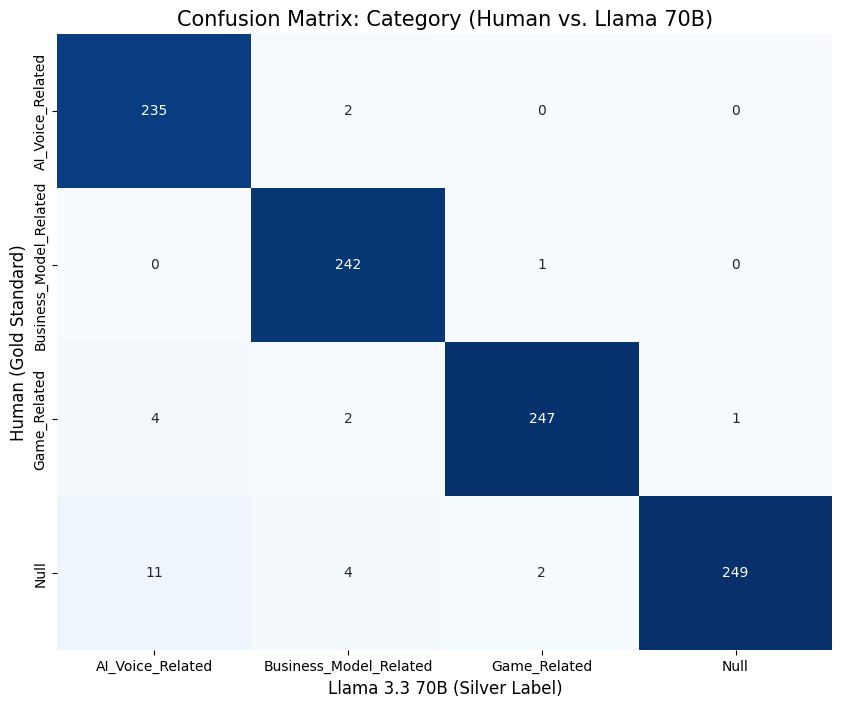


 VALIDATION: SENTIMENT
Percent Agreement:     0.970
Gwet's AC1:            0.964 (Paradox Resistant)
Cohen's Kappa (Unweighted): 0.956
Cohen's Kappa (quadratic):   0.965

Detailed Classification Report:
              precision    recall  f1-score   support

  Ambivalent       0.75      1.00      0.86        12
         Neg       0.97      0.99      0.98       447
         Neu       0.97      0.97      0.97       103
        Null       1.00      0.94      0.97       266
         Pos       0.94      0.97      0.96       172

    accuracy                           0.97      1000
   macro avg       0.93      0.97      0.95      1000
weighted avg       0.97      0.97      0.97      1000



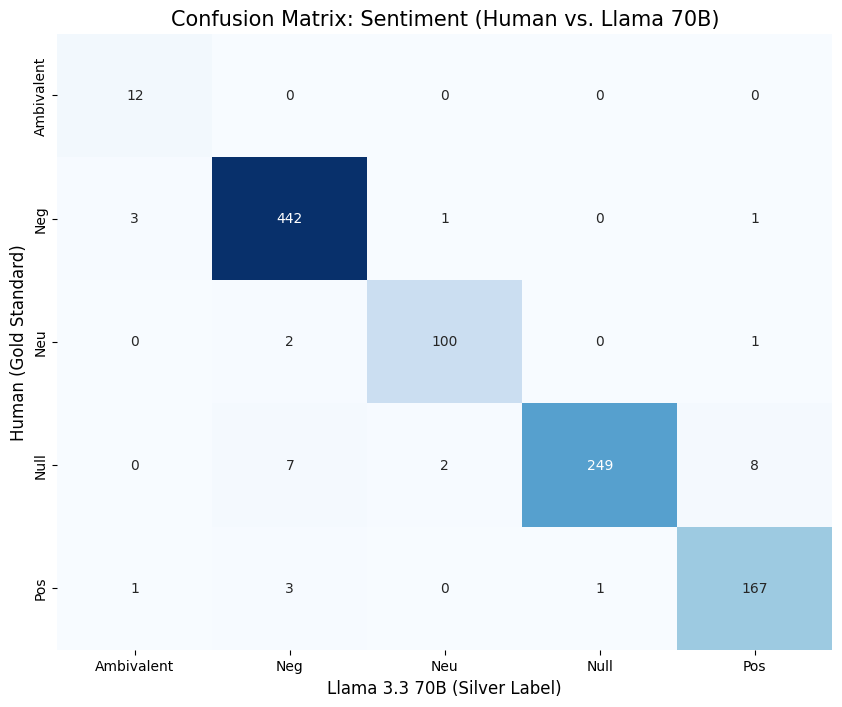

In [37]:
# ANALYSIS

# For Category (Aspect): Nominal data, usually no weights
plot_and_calculate('category', weight_type=None)

# For Sentiment: Ordinal data (Neg < Neu < Pos). 
# 'quadratic' weights penalize a (Neg vs Pos) error more than a (Neg vs Neu) error
plot_and_calculate('sentiment', weight_type='quadratic')